# Netflix Content Strategy Analysis

## Business Problem

Netflix operates globally and continuously expands its content catalog through content acquisition and original productions.

The objective of this project is to analyze Netflix's content library and identify patterns in content type, genre, country of origin, release trends, audience ratings, and content growth over time.

The insights generated can help understand Netflix's content strategy and support future content investment decisions.

## Dataset Description

The dataset contains information about Netflix movies and TV shows available on the platform.

Key attributes include:

- Title
- Type (Movie or TV Show)
- Director
- Cast
- Country
- Date Added
- Release Year
- Rating
- Duration
- Genre

The dataset consists of more than 8,800 titles and provides a comprehensive view of Netflix's content catalog.

In [58]:
# import libraries

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# load dataset

df = pd.read_csv('/Users/sahiti/Downloads/netflix_titles.csv')

# Initial Data Exploration

Before performing any analysis, we first explore the dataset structure, dimensions, data types, and summary statistics to understand the available information.

In [59]:
# Initial Data Exploration

df.shape

(8807, 12)

In [60]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [61]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


# Data Quality Assessment

Data quality assessment helps identify missing values, duplicate records, and potential inconsistencies that may impact analysis results.

In [63]:
# Check Duplicate Values

duplicate_value = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_value )

Number of duplicate rows: 0


In [64]:
df["show_id"].duplicated().sum()

0

In [65]:
# Check Missing Values

df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [66]:
# Checking missing value in percentage

missing_values = round(((df.isnull().sum() / len(df)) * 100),2)

missing_values.sort_values(ascending=False)

director        29.91
country          9.44
cast             9.37
date_added       0.11
rating           0.05
duration         0.03
show_id          0.00
type             0.00
title            0.00
release_year     0.00
listed_in        0.00
description      0.00
dtype: float64

In [67]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

# Data Cleaning

Data cleaning is performed to improve data quality and ensure consistency before conducting exploratory analysis.

In [68]:
# fill all missing values

df["director"] = ( df["director"].fillna("Unknown"))
df["country"] = (df["country"].fillna("Unknown"))
df["cast"] = (df["cast"].fillna("Unknown"))
df["rating"] = ( df["rating"].fillna("Not Rated"))
df["duration"] = ( df["duration"].fillna("Unknown"))



In [69]:
df["date_added"].head()

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: str

In [70]:
# convert date

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [71]:
df["date_added"].dtype

dtype('<M8[us]')

In [72]:
df.isna().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [73]:
# Spliting the date 
# Added astype('Int64') because the year is float due to NaT values.

df["year_added"] = (df["date_added"].dt.year.astype("Int64"))
df["year_added"]

0       2021
1       2021
2       2021
3       2021
4       2021
        ... 
8802    2019
8803    2019
8804    2019
8805    2020
8806    2019
Name: year_added, Length: 8807, dtype: Int64

In [74]:
df["year_added"] = (df["date_added"].dt.year.astype("Int64"))
df["year_added"]

0       2021
1       2021
2       2021
3       2021
4       2021
        ... 
8802    2019
8803    2019
8804    2019
8805    2020
8806    2019
Name: year_added, Length: 8807, dtype: Int64

In [75]:
df["month_num"] = (df["date_added"].dt.month.astype("Int64"))
df["month_name"] = df["date_added"].dt.month_name()


In [76]:
# Caluculate the content age

df["content_age"] = datetime.now().year - df["release_year"]

df["content_age"]

0        6
1        5
2        5
3        5
4        5
        ..
8802    19
8803     8
8804    17
8805    20
8806    11
Name: content_age, Length: 8807, dtype: int64

In [77]:
# Extract number + unit from the movie duration

df["duration_num"] = (df["duration"].str.extract(r"(\d+)"))

df["duration_num"] = pd.to_numeric(df["duration_num"])

df["duration_unit"] = (df["duration"].str.extract(r"([A-Za-z ]+)$"))

In [78]:
df["duration_unit"]

0            min
1        Seasons
2         Season
3         Season
4        Seasons
          ...   
8802         min
8803     Seasons
8804         min
8805         min
8806         min
Name: duration_unit, Length: 8807, dtype: str

In [79]:
df['duration_unit'].unique()

<ArrowStringArray>
[' min', ' Seasons', ' Season', 'Unknown']
Length: 4, dtype: str

In [80]:
df['rating'].value_counts()

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64

In [81]:
df[df["rating"].isin(["74 min","84 min","66 min"])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_num,month_name,content_age,duration_num,duration_unit
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,Unknown,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017,4,April,9,NaN,Unknown
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,Unknown,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016,9,September,16,NaN,Unknown
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,Unknown,Movies,The comic puts his trademark hilarious/thought...,2016,8,August,11,NaN,Unknown


In [82]:
mask = df["rating"].str.contains("min", na=False)

df.loc[mask, "duration"] = df.loc[mask, "rating"]

df.loc[mask, "rating"] = "Not Rated"

In [83]:
df['rating'].unique()

<ArrowStringArray>
[    'PG-13',     'TV-MA',        'PG',     'TV-14',     'TV-PG',      'TV-Y',
     'TV-Y7',         'R',      'TV-G',         'G',     'NC-17', 'Not Rated',
        'NR',  'TV-Y7-FV',        'UR']
Length: 15, dtype: str

In [84]:
df.head(20)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_num,month_name,content_age,duration_num,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,September,6,90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,September,5,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,September,5,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,September,5,1.0,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,September,5,2.0,Seasons
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021,9,September,5,1.0,Season
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,9,September,5,91.0,min
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9,September,33,125.0,min
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,2021,9,September,5,9.0,Seasons
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,9,September,5,104.0,min


### Exploratory Data Analysis

## Q1. Does Netflix offer more Movies or TV Shows?

Understanding the distribution of content types helps identify Netflix's primary content strategy.

In [85]:
# Movies vs TV Shows

df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

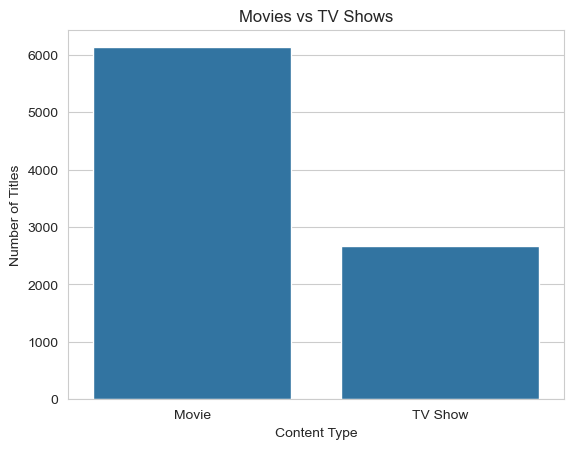

In [86]:
sns.countplot(
    data=df,
    x="type" 
)

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

### Insight

Movies constitute the majority of Netflix's catalog, suggesting that film acquisition and production remain a significant component of Netflix's content strategy.

## Q2. How has Netflix's content catalog grown over time?

Analyzing yearly additions helps identify periods of accelerated platform expansion.

In [87]:
# Content Added Over Time

content_added = (df["year_added"].value_counts().sort_index())

content_added

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: Int64

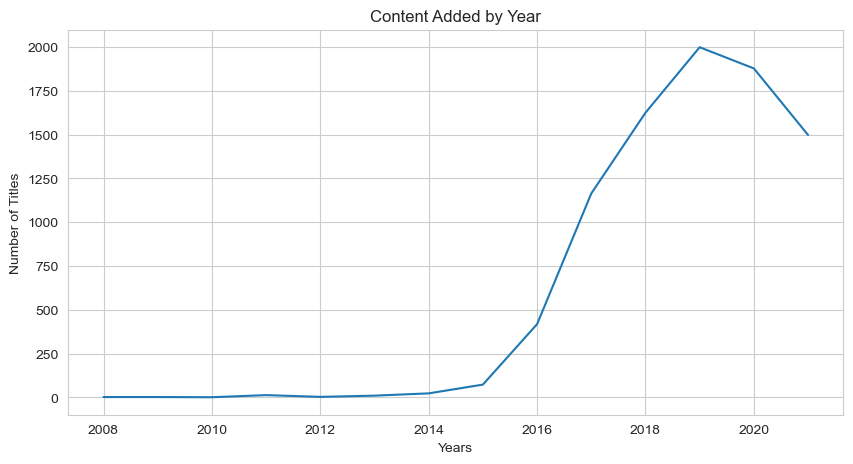

In [88]:
content_added.plot(
    kind="line",
    figsize=(10,5)
)

plt.title("Content Added by Year")
plt.xlabel("Years")
plt.ylabel("Number of Titles")

plt.show()

### Insight

The number of titles added increased substantially after 2015, reflecting Netflix's rapid global expansion and increased investment in content.

## Q3. Which countries contribute the most content to Netflix?

Country-level analysis helps identify key content-producing regions within Netflix's catalog.

In [89]:
# Top 10 Countries

country_df = df.copy()

country_df["country"] = (
    country_df["country"]
    .str.split(",")
)

country_df = (
    country_df
    .explode("country")
)

country_df["country"] = (
    country_df["country"]
    .str.strip()
)


In [90]:
top_countries = (
    country_df["country"]
    .value_counts()
    .head(10)
)

top_countries

country
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

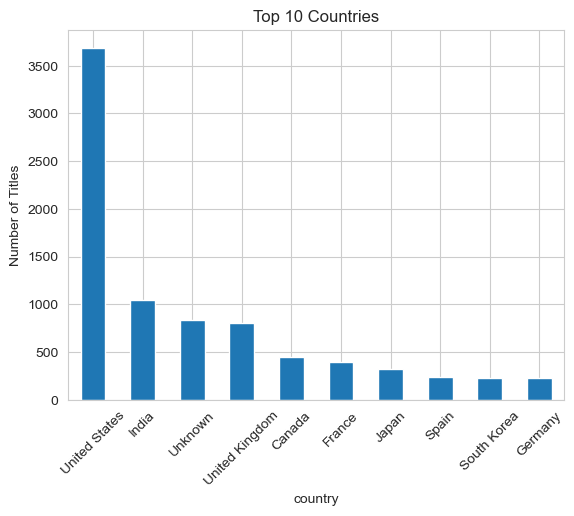

In [91]:
top_countries.plot(
    kind="bar"
)

plt.title(
    "Top 10 Countries"
)
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

### Insight

The United States contributes the largest share of content, followed by several other major entertainment markets, indicating geographic concentration within the catalog.

## Q4. Which genres are most common on Netflix?

Genre analysis helps identify the types of content that dominate Netflix's platform.

In [92]:
# Top Genres

genre_df = df.copy()

genre_df["listed_in"] = (
    genre_df["listed_in"]
    .str.split(",")
)

genre_df = (
    genre_df
    .explode("listed_in")
)

genre_df["listed_in"] = (
    genre_df["listed_in"]
    .str.strip()
)

In [93]:
top_genres = (
    genre_df["listed_in"]
    .value_counts()
    .head(10)
)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

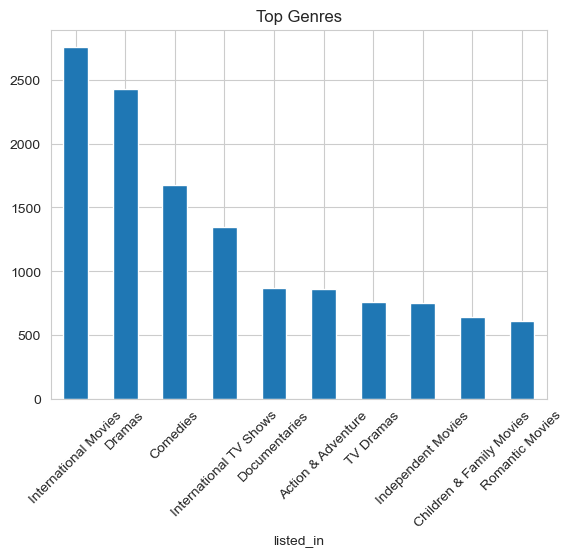

In [94]:
top_genres.plot(
    kind="bar"
)

plt.title(
    "Top Genres"
)

plt.xticks(rotation=45)

plt.show()

### Insight

Drama, International Movies, and Comedy appear among the most common genres, demonstrating Netflix's emphasis on broad audience appeal and global content diversity.

## Q5. What audience ratings dominate Netflix's catalog?

Content ratings provide insight into Netflix's target audience demographics.

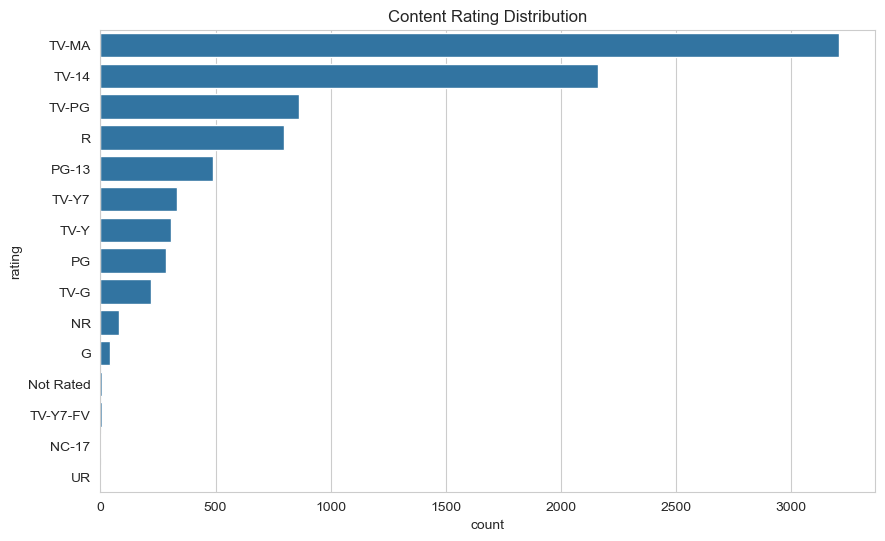

In [95]:
# Rating Distribution

plt.figure(
    figsize=(10,6)
)

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"]
    .value_counts()
    .index
)

plt.title(
    "Content Rating Distribution"
)

plt.show()

### Insight

A large proportion of titles are rated for mature audiences, indicating strong focus on adult-oriented content.

## Q6. How has content production changed over time?

Release year analysis helps understand the age profile and evolution of Netflix's content catalog.

By examining title release years, we can identify periods of increased content production and understand whether Netflix primarily hosts recent or older content.

In [96]:
# Content Production Trend by Release Year

release_year_trend = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

release_year_trend.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: count, dtype: int64

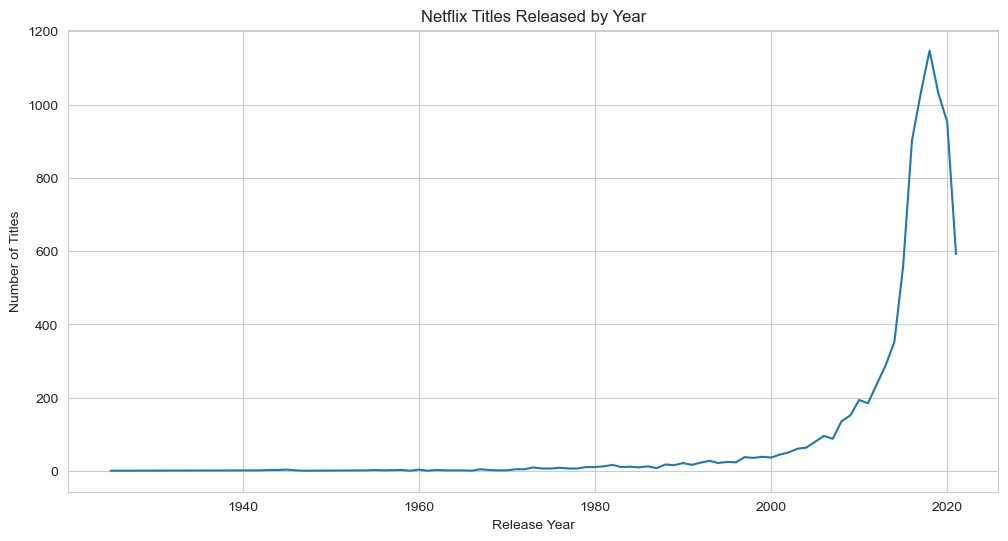

In [97]:
plt.figure(figsize=(12,6))

release_year_trend.plot(kind="line")

plt.title("Netflix Titles Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

### Insight

Most Netflix titles were released in recent years, suggesting that the platform maintains a relatively modern content catalog. The increase in releases after 2000 reflects the growth of digital content production and streaming services.

## Q7. What is the typical duration of Netflix movies?

Movie duration analysis helps understand content consumption patterns and production preferences.

This analysis focuses only on movies and excludes TV Shows because TV Show duration represents seasons rather than runtime.

In [98]:
# Filter only movies

movies_df = df[df["type"] == "Movie"]

movies_df[["title","duration_num"]].head()

,title,duration_num
0,Dick Johnson Is Dead,90.0
6,My Little Pony: A New Generation,91.0
7,Sankofa,125.0
9,The Starling,104.0
12,Je Suis Karl,127.0


In [99]:
movies_df["duration_num"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_num, dtype: float64

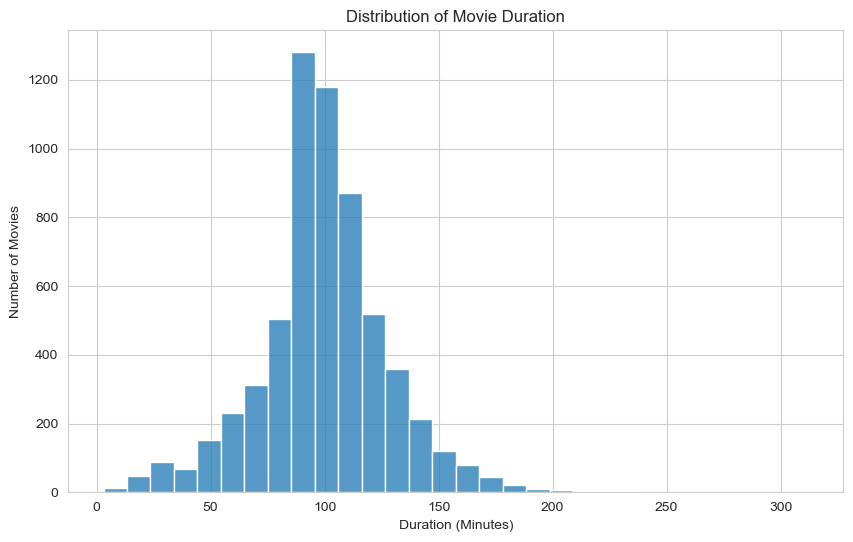

In [100]:
plt.figure(figsize=(10,6))

sns.histplot(
    movies_df["duration_num"],
    bins=30
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

### Insight

Most Netflix movies fall within a standard feature-film runtime range of approximately 80–120 minutes. This indicates a strong preference for traditional movie formats that align with audience viewing habits.

## Q8. Which actors appear most frequently on Netflix?

Actor analysis helps identify recurring talent across Netflix titles.

In [101]:
# Top 10 Actors on Netflix


actor_df = df.copy()

actor_df["cast"] = actor_df["cast"].str.split(",")

actor_df = actor_df.explode("cast")

actor_df["cast"] = actor_df["cast"].str.strip()

top_actors = (
    actor_df[actor_df["cast"] != "Unknown"]["cast"]
    .value_counts()
    .head(10)
)

top_actors

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

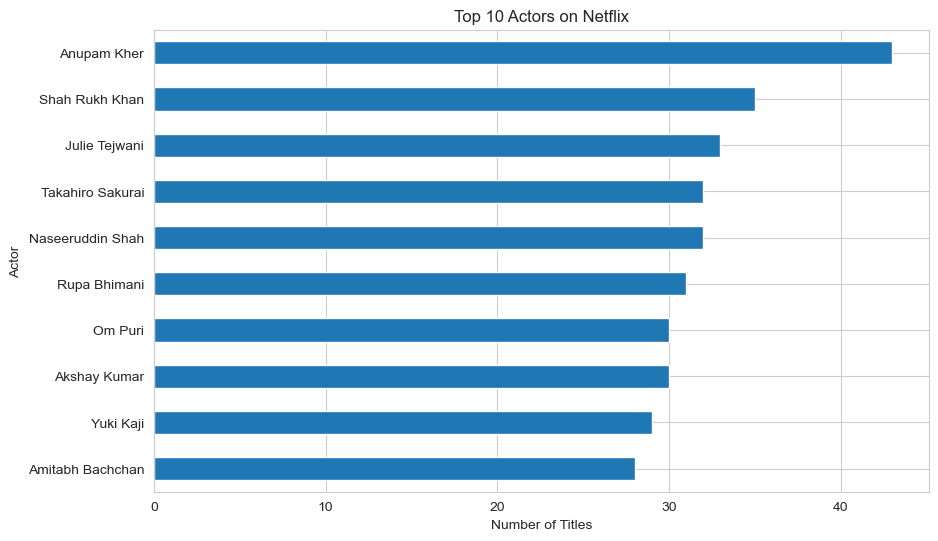

In [102]:
plt.figure(figsize=(10,6))

top_actors.sort_values().plot(kind="barh")

plt.title("Top 10 Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.show()

### Insight

Several actors appear repeatedly across the catalog, reflecting strong partnerships with production companies and recurring casting patterns.

## Q9. Which directors have the highest number of titles on Netflix?

Director analysis highlights influential content creators within the Netflix ecosystem.

In [103]:
# Top Directors Analysis

top_directors = (
    df[df["director"] != "Unknown"]["director"]
    .value_counts()
    .head(10)
)

top_directors

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

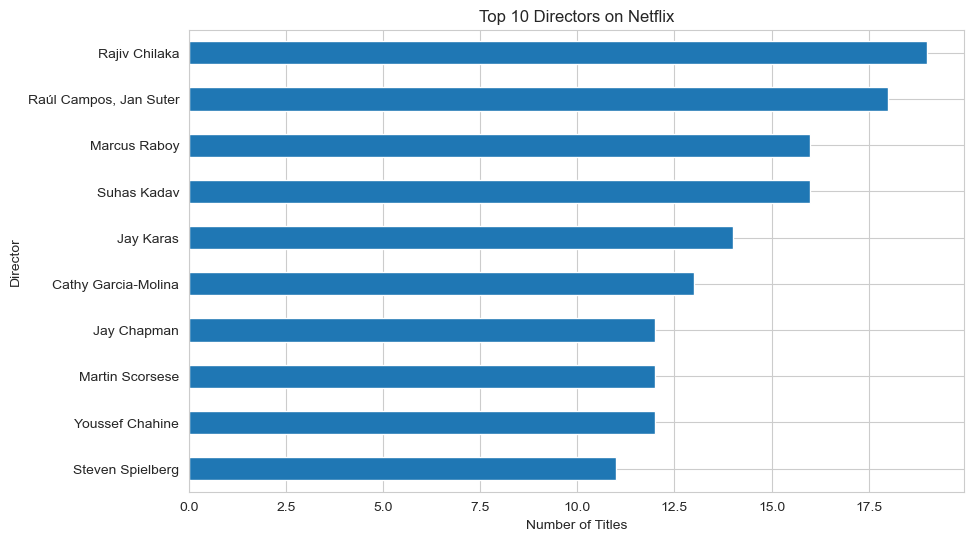

In [104]:
plt.figure(figsize=(10,6))

top_directors.sort_values().plot(kind="barh")

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

### Insight

A small group of directors contributes multiple titles, demonstrating recurring creative relationships across productions.

## Q10. How many seasons do Netflix TV Shows typically have?

Season analysis helps understand the prevalence of long-running versus limited-series content.

In [105]:
# TV Show Season Analysis

tv_shows = df[df["type"] == "TV Show"]

In [106]:
tv_shows["duration_num"].mean()

1.764947683109118

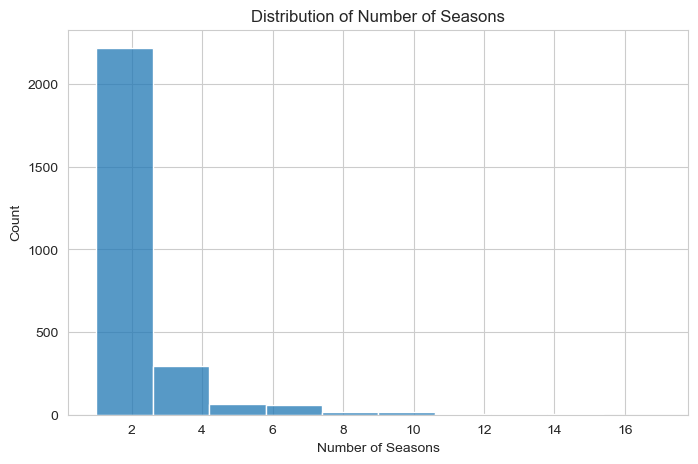

In [107]:
plt.figure(figsize=(8,5))

sns.histplot(
    tv_shows["duration_num"],
    bins=10
)

plt.title("Distribution of Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Count")

plt.show()

In [108]:
season_distribution = (
    tv_shows["duration_num"]
    .value_counts()
    .sort_index()
)

season_distribution

duration_num
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64

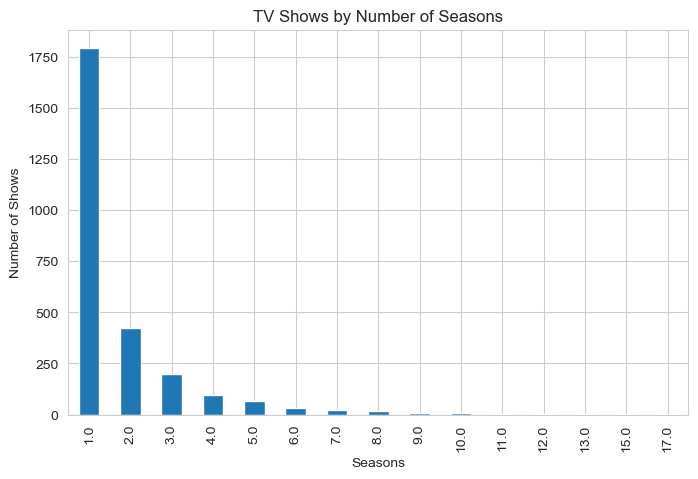

In [109]:
plt.figure(figsize=(8,5))

season_distribution.plot(kind="bar")

plt.title("TV Shows by Number of Seasons")
plt.xlabel("Seasons")
plt.ylabel("Number of Shows")

plt.show()

### Insight

Most TV Shows contain only one season, indicating a large share of limited series or recently launched productions.

## Q11. During which months is content most frequently added?

Monthly analysis helps identify seasonal patterns in content acquisition and release activity.

In [110]:
# Month Added Analysis

month_added_analysis = (
    df["month_name"]
    .value_counts()
)

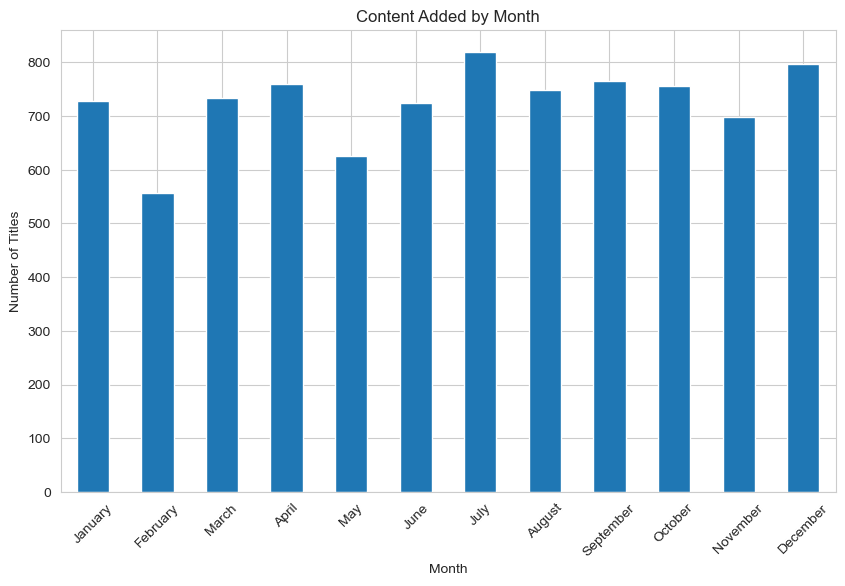

In [111]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

month_added_analysis = (
    df["month_name"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(10,6))

month_added_analysis.plot(kind="bar")

plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

### Insight

Content additions are not evenly distributed throughout the year, suggesting strategic scheduling of releases and acquisitions.

In [113]:
# Downloading the clean data

df.to_csv("netflix_cleaned.csv", index=False)

print('File has been downloaded')

File has been downloaded


## Key Insights

1. Movies dominate Netflix's content library.

2. Content additions accelerated significantly after 2015.

3. The United States contributes the largest share of content.

4. Drama and International Movies are among the most common genres.

5. Mature audience ratings dominate the platform.

6. Most TV shows have only one season.

7. Netflix content additions peak during specific months of the year.

## Recommendations

1. Continue investing in genres with strong representation and audience demand.

2. Expand content acquisition from emerging markets to reduce reliance on a few countries.

3. Increase production of successful multi-season TV shows to improve subscriber retention.

4. Align content releases with historically strong content addition periods.

## Conclusion

This analysis explored more than 8,800 Netflix titles to understand content distribution, growth trends, audience targeting, and regional contributions.

The findings indicate that Netflix's catalog is heavily movie-focused, driven primarily by content from the United States and other major entertainment markets. Drama and International Movies dominate the platform, while most TV Shows consist of a single season. The platform also experienced substantial catalog expansion after 2015, reflecting Netflix's global growth strategy.

These insights can support content acquisition, production planning, and audience engagement strategies.